In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('../../data/raw_tsv_data/TCGA-BRCA.star_tpm.tsv', delimiter='\t')

In [4]:
df.head()

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003.15,5.662037,3.703721,6.514515,4.784917,4.251984,3.536849,4.645690,6.021755,6.260931,...,4.825501,4.142806,4.960919,4.770121,5.276757,6.436490,6.184500,2.670931,6.834395,3.650719
1,ENSG00000000005.6,3.376096,0.463099,0.000000,2.328061,0.435415,0.736475,1.255622,0.392647,0.467593,...,0.134747,0.159500,0.079566,3.312418,0.000000,0.383608,0.755144,0.479644,0.526069,0.059909
2,ENSG00000000419.13,6.860140,7.086452,6.805072,6.443071,6.178436,6.823355,5.749910,6.977449,6.819887,...,6.382933,6.436308,6.994589,6.005000,7.382161,7.220846,6.868277,7.033110,6.384368,8.153019
3,ENSG00000000457.14,4.400552,4.051007,5.037264,4.374970,3.558464,2.108324,4.487107,4.021000,3.319560,...,3.891448,3.765057,4.946796,3.648707,3.664915,3.752192,4.093078,4.831796,4.368028,4.172247
4,ENSG00000000460.17,2.845169,2.426989,4.043248,4.162790,2.589548,2.277777,2.545178,3.372492,4.023974,...,2.557655,2.566596,3.746915,2.494160,3.104957,3.111549,2.538538,3.730901,3.311721,3.301075


In [5]:
df.shape

(60660, 1227)

In [34]:
df_clean = df.drop(columns=['Ensembl_ID'])

In [13]:
df_clean.lt(0).sum().sum()

0

In [24]:
df_brca = pd.read_csv('/scratch/2370352/my-research/repo/src/data/files/tcga_brca/HiSeqV2_PANCAN_BRCA', sep='\t')

In [25]:
df_brca.head()

,sample,TCGA-AR-A5QQ-01,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AC-A5XU-01,TCGA-PE-A5DE-01,...,TCGA-A7-A13E-11,TCGA-C8-A8HP-01,TCGA-E9-A5FL-01,TCGA-AC-A2FB-11,TCGA-E2-A15F-01,TCGA-A2-A3XT-01,TCGA-B6-A0X7-01,TCGA-BH-A1EV-11,TCGA-3C-AALJ-01,TCGA-B6-A0X1-01
0,ARHGEF10L,-0.356592,-2.429392,-0.542392,-0.844192,-0.222292,-0.097492,0.229108,-0.711592,0.075808,...,-0.237492,0.318608,0.055908,0.045008,0.169408,1.650408,0.710508,-0.459192,1.082808,0.452408
1,HIF3A,-3.976026,-1.894026,-2.832326,-4.213326,-4.972826,-5.280926,-1.945726,-5.080926,-2.616926,...,2.599874,-3.338826,-1.690226,2.632474,-4.671126,-4.237826,-1.485126,1.698974,-4.623726,-3.135626
2,RNF17,-0.531035,0.093465,0.021565,-0.531035,-0.531035,0.345465,-0.531035,-0.531035,-0.531035,...,-0.531035,-0.531035,3.199465,-0.531035,-0.531035,0.601865,-0.105235,-0.531035,-0.531035,-0.531035
3,RNF10,-0.409972,0.140528,0.188928,1.410528,0.226028,0.034228,-0.395572,-0.277172,0.427928,...,0.209328,0.487728,0.703928,0.048728,0.235928,-0.195772,0.088728,-0.231572,0.484028,0.379428
4,RNF11,0.161322,2.559422,0.442622,0.123222,0.286622,-0.112478,-0.201578,-0.532078,0.253122,...,0.966522,0.443822,-0.477678,0.607522,-0.130878,-0.694278,-0.203478,0.909522,-0.183678,0.274122


In [26]:
df_brca_clean = df_brca.drop(columns=['sample'])
# df_brca_clean = df_brca.drop(columns=['Unnamed: 0    ', 'Unnamed: 0.1'])

In [ ]:
df_brca.describe().T[["min", "max"]]

,min,max
TCGA-AR-A5QQ-01,-6.167341,13.396742
TCGA-D8-A1JA-01,-7.617768,12.501401
TCGA-BH-A0BQ-01,-7.658593,10.805647
TCGA-BH-A0BT-01,-6.155706,13.937092
TCGA-A8-A06X-01,-6.784134,10.438919
...,...,...
TCGA-A2-A3XT-01,-6.423570,10.034808
TCGA-B6-A0X7-01,-7.485429,11.848592
TCGA-BH-A1EV-11,-7.658593,13.183030
TCGA-3C-AALJ-01,-7.709537,12.796713


In [28]:
row_means = df_brca_clean.mean(axis=1)
col_means = df_brca_clean.mean(axis=0)

row_means, col_means

(0       -0.193420
 1       -2.195821
 2       -0.255530
 3        0.077378
 4        0.165997
            ...   
 20525    0.398565
 20526    0.635816
 20527   -0.026144
 20528    0.853730
 20529   -0.005872
 Length: 20530, dtype: float64,
 TCGA-AR-A5QQ-01    0.037786
 TCGA-D8-A1JA-01   -0.223715
 TCGA-BH-A0BQ-01    0.112055
 TCGA-BH-A0BT-01   -0.024218
 TCGA-A8-A06X-01   -0.224994
                      ...   
 TCGA-A2-A3XT-01   -0.010564
 TCGA-B6-A0X7-01    0.075183
 TCGA-BH-A1EV-11    0.272289
 TCGA-3C-AALJ-01    0.019827
 TCGA-B6-A0X1-01   -0.024427
 Length: 1218, dtype: float64)

In [29]:
row_means.abs().mean(), col_means.abs().mean()

(0.4416851731594936, 0.12192432735144991)

(array([1.000000e+00, 0.000000e+00, 0.000000e+00, 1.000000e+00,
        0.000000e+00, 0.000000e+00, 1.000000e+00, 1.000000e+00,
        4.000000e+00, 1.000000e+00, 4.000000e+00, 1.000000e+00,
        4.000000e+00, 8.000000e+00, 5.000000e+00, 1.000000e+01,
        2.200000e+01, 1.200000e+01, 3.000000e+01, 2.000000e+01,
        5.800000e+01, 6.600000e+01, 2.640000e+02, 1.480000e+02,
        2.060000e+02, 1.700000e+02, 2.250000e+02, 4.280000e+02,
        4.150000e+02, 4.320000e+02, 6.920000e+02, 9.170000e+02,
        2.071000e+03, 1.589000e+03, 2.618000e+03, 2.559000e+03,
        2.982000e+03, 4.678000e+03, 5.773000e+03, 6.761000e+03,
        8.601000e+03, 1.136000e+04, 1.129500e+04, 1.560500e+04,
        2.017900e+04, 2.115200e+04, 2.792600e+04, 3.245900e+04,
        3.772600e+04, 4.735100e+04, 5.438100e+04, 6.623600e+04,
        8.085800e+04, 9.787400e+04, 1.107110e+05, 1.384190e+05,
        1.694320e+05, 1.994710e+05, 2.240610e+05, 2.718890e+05,
        3.183270e+05, 3.892960e+05, 4.47

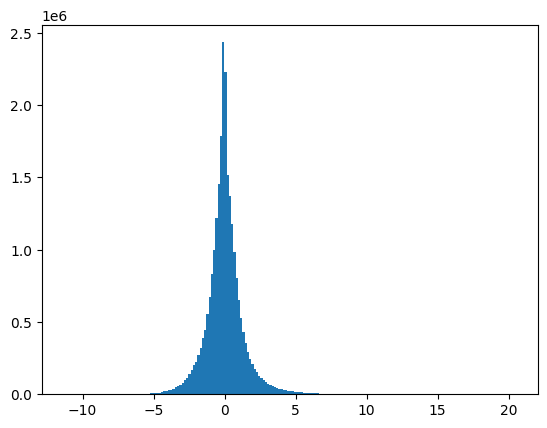

In [30]:
import matplotlib.pyplot as plt
plt.hist(df_brca_clean.values.flatten(), bins=200)


(array([3.8183358e+07, 3.5045330e+06, 2.4845580e+06, 1.8119810e+06,
        1.4493800e+06, 1.2423790e+06, 1.0866810e+06, 9.5035900e+05,
        8.3839700e+05, 7.4980900e+05, 6.8102600e+05, 6.2368100e+05,
        5.7681000e+05, 5.3732400e+05, 5.0303400e+05, 4.7510600e+05,
        4.5002600e+05, 4.2713200e+05, 4.0751800e+05, 3.9331300e+05,
        3.7817500e+05, 3.6741700e+05, 3.5713900e+05, 3.4797300e+05,
        3.4171500e+05, 3.3631300e+05, 3.3124300e+05, 3.2716100e+05,
        3.2625200e+05, 3.2473600e+05, 3.2530700e+05, 3.2508400e+05,
        3.2581700e+05, 3.2785700e+05, 3.2968000e+05, 3.3241300e+05,
        3.3454300e+05, 3.3824900e+05, 3.4063800e+05, 3.4427700e+05,
        3.4600100e+05, 3.4745400e+05, 3.4871400e+05, 3.4902900e+05,
        3.4851800e+05, 3.4857700e+05, 3.4801100e+05, 3.4545500e+05,
        3.4270600e+05, 3.3895600e+05, 3.3414700e+05, 3.2772300e+05,
        3.2101100e+05, 3.1316400e+05, 3.0524600e+05, 2.9613400e+05,
        2.8670000e+05, 2.7644900e+05, 2.6666700e

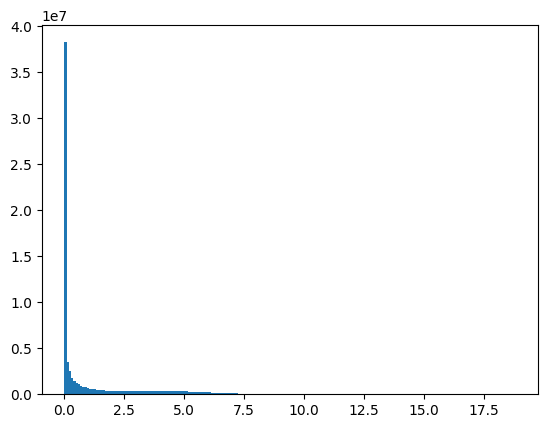

In [35]:
plt.hist(df_clean.values.flatten(), bins=200)


In [36]:
expr_log = df_clean.copy()

# Standaryzacja per gen (wiersz)
expr_z = expr_log.sub(expr_log.mean(axis=1), axis=0)  # odejmij średnią per gen
expr_z = expr_z.div(expr_log.std(axis=1), axis=0)

In [39]:
scaler = StandardScaler(with_mean=True, with_std=True)
expr_z1 = pd.DataFrame(
    scaler.fit_transform(expr_log.T).T,
    index=expr_log.index,
    columns=expr_log.columns
)

In [41]:
print(expr_z1.mean(axis=1).abs().mean())  # średnia per gen ≈ 0
print(expr_z1.std(axis=1).mean())         # SD per gen ≈ 1


1.3248884319762287e-15
0.9573308313201199


(array([1.0000000e+00, 0.0000000e+00, 1.0000000e+00, 0.0000000e+00,
        3.0000000e+00, 4.0000000e+00, 7.0000000e+00, 9.0000000e+00,
        4.0000000e+00, 1.0000000e+01, 1.4000000e+01, 2.7000000e+01,
        2.6000000e+01, 3.8000000e+01, 5.9000000e+01, 9.6000000e+01,
        1.2800000e+02, 1.5900000e+02, 2.6000000e+02, 3.7600000e+02,
        5.4800000e+02, 7.0600000e+02, 1.0180000e+03, 1.4280000e+03,
        2.0290000e+03, 2.8220000e+03, 3.7480000e+03, 5.1620000e+03,
        7.2850000e+03, 1.0192000e+04, 1.4643000e+04, 2.1194000e+04,
        3.1231000e+04, 4.7310000e+04, 7.2958000e+04, 1.1401500e+05,
        1.8291800e+05, 2.9933600e+05, 5.0063500e+05, 8.6617300e+05,
        1.5233700e+06, 2.6956120e+06, 4.7662820e+06, 8.7864440e+06,
        1.8962603e+07, 1.3293385e+07, 3.9691920e+06, 3.3608550e+06,
        2.7692540e+06, 2.1990790e+06, 1.6856670e+06, 1.2519320e+06,
        9.0862500e+05, 6.5277800e+05, 4.6857800e+05, 3.4119000e+05,
        2.5011800e+05, 1.8654600e+05, 1.4198400e

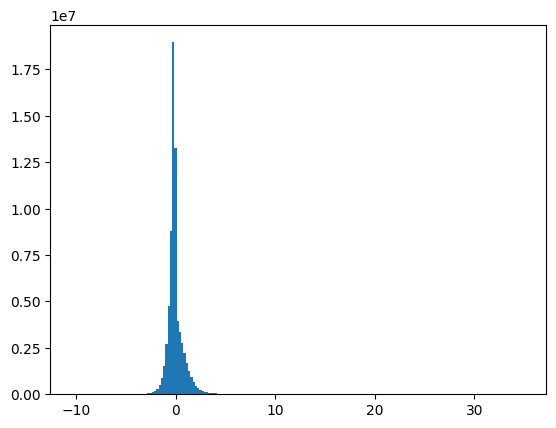

In [43]:
plt.hist(expr_z.values.flatten(), bins=200)
